## Import the Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker
from math import floor

## Load the data

In [2]:
df = pd.read_csv("C:\\Users\\abhay\\OneDrive\\Desktop\\Data-Analytics-Portfolio\\05_End-To-End-Project\\Ecommerce_sales_analysis_avd\\Data\\cleaned_ecommerce_data.csv")
df["order_date"] = pd.to_datetime(df["order_date"])
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 16 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   order_id        2000 non-null   str           
 1   order_date      2000 non-null   datetime64[us]
 2   customer_id     2000 non-null   str           
 3   customer_name   2000 non-null   str           
 4   age             2000 non-null   float64       
 5   gender          2000 non-null   str           
 6   city            2000 non-null   str           
 7   product         2000 non-null   str           
 8   category        2000 non-null   str           
 9   quantity        2000 non-null   int64         
 10  unit_price      2000 non-null   float64       
 11  discount_pct    2000 non-null   int64         
 12  revenue         2000 non-null   float64       
 13  payment_method  2000 non-null   str           
 14  returned        2000 non-null   bool          
 15  rating         

## Analysis

- Total revenue by year

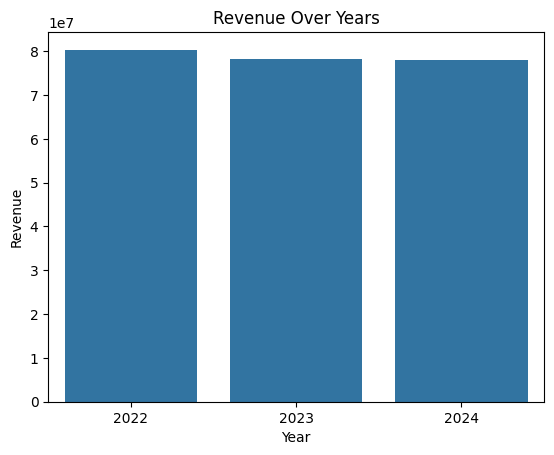

In [3]:
df_year = df.groupby(df["order_date"].dt.year)["revenue"].sum()

sns.barplot(x=df_year.index, y=df_year.values)

plt.xlabel("Year")
plt.ylabel("Revenue")
plt.title("Revenue Over Years")
plt.show()

- Total revenue over month in past years

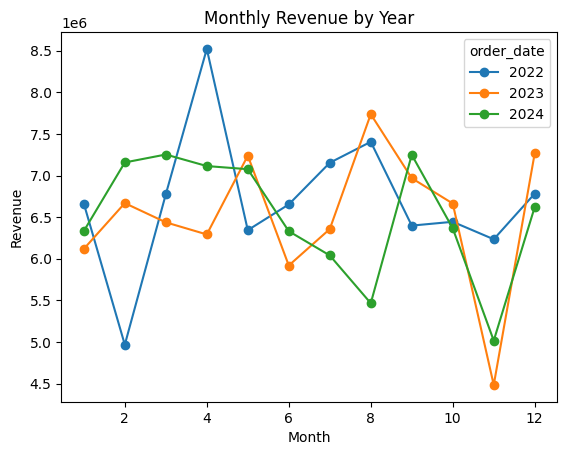

In [4]:
df_month = df.pivot_table(
                values="revenue",
                index=df["order_date"].dt.year,
                columns=df["order_date"].dt.month,
                aggfunc="sum"
            )

df_month.T.plot(marker='o')

plt.xlabel("Month")
plt.ylabel("Revenue")
plt.title("Monthly Revenue by Year")
plt.show()

- Top 10 Coustomers of the company

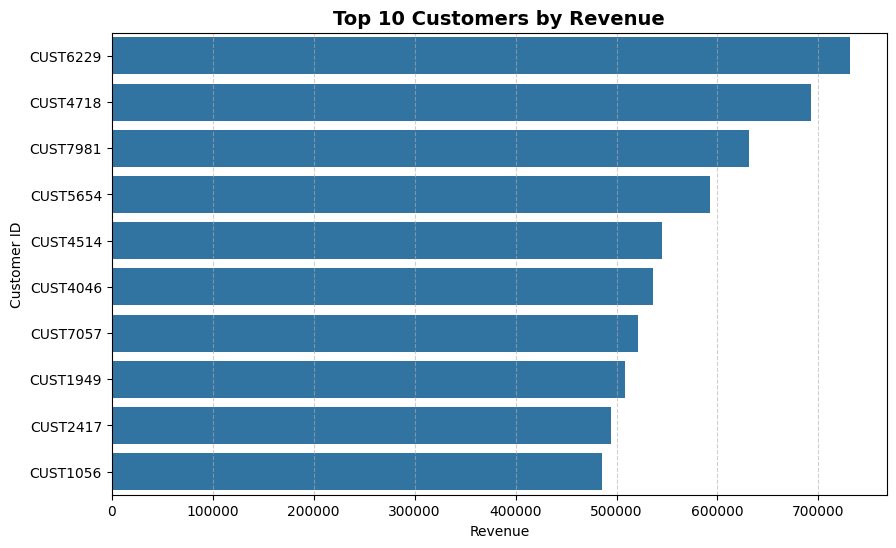

In [3]:
df_VIP = df.groupby("customer_id")["revenue"].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))

ax = sns.barplot(x=df_VIP.values, y=df_VIP.index)

plt.title("Top 10 Customers by Revenue", fontsize=14, weight="bold")
plt.xlabel("Revenue")
plt.ylabel("Customer ID")

plt.grid(axis="x", linestyle="--", alpha=0.6)

plt.show()

- Top 10 products

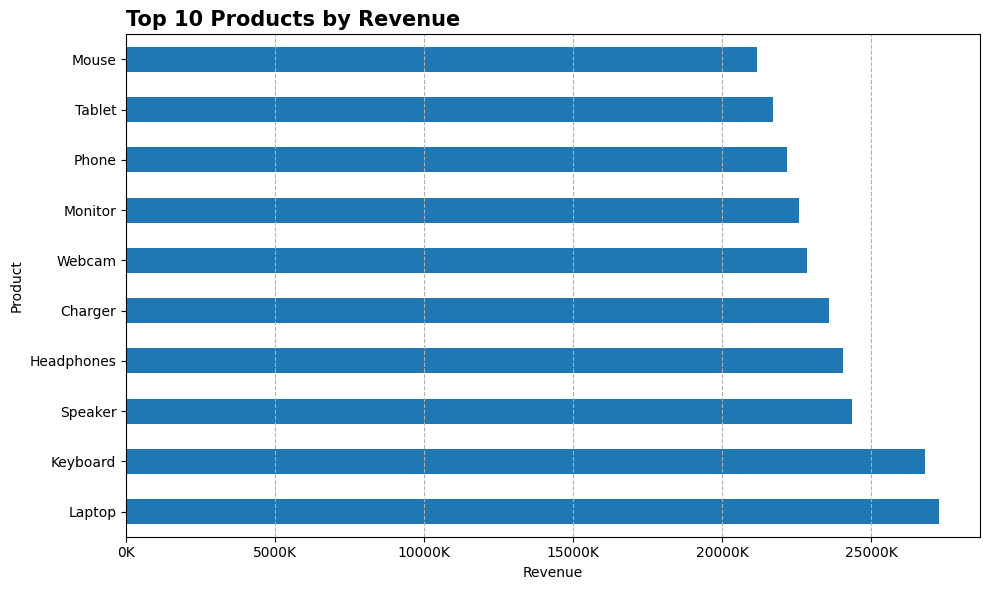

In [6]:
df_pro = df.groupby('product')['revenue'].sum().sort_values(ascending=False).head(10)

ax = df_pro.plot(kind='barh', figsize=(10,6))

plt.xlabel("Revenue")
plt.ylabel("Product")
plt.title("Top 10 Products by Revenue", fontsize=15, weight='bold', loc='left')

ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{int(x/1000)}K'))
plt.grid(axis='x', linestyle='--', alpha=1)

plt.tight_layout()
plt.show()

- Most prefered payment mode by top customers

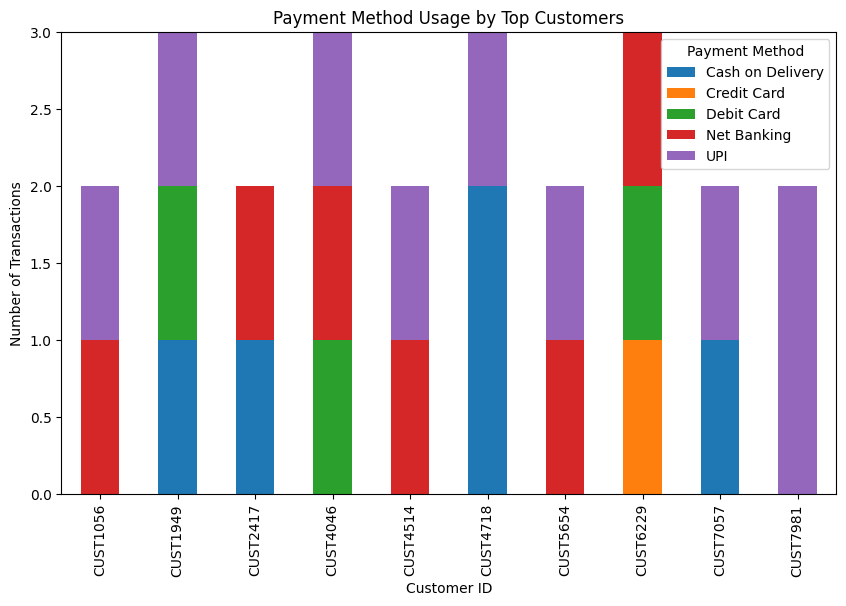

In [19]:
df_VIP = (
    df.groupby("customer_id")["revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

df_top = df[df["customer_id"].isin(df_VIP.index)]

pivot = df_top.pivot_table(
    index="customer_id",
    columns="payment_method",
    aggfunc="size",
    fill_value=0
)

pivot.plot(kind="bar",stacked=True,  figsize=(10,6))

plt.xlabel("Customer ID")
plt.ylabel("Number of Transactions")
plt.title("Payment Method Usage by Top Customers")
plt.legend(title="Payment Method")

plt.show()

- Top 5 and bottom 5 cities by total revenue

In [27]:
print("The Top 5 city by revenue is ")
print(df.groupby('city')['revenue'].sum().sort_values(ascending=False).head())

print("The Bottem 5 city by revenue is ")
print(df.groupby('city')['revenue'].sum().sort_values(ascending=False).tail())

The Top 5 city by revenue is 
city
Mumbai       34267662.17
Kolkata      32650459.66
Bangalore    29798841.61
Pune         29786289.78
Chennai      28224423.30
Name: revenue, dtype: float64
The Bottem 5 city by revenue is 
city
Pune         29786289.78
Chennai      28224423.30
Delhi        27695879.18
Ahmedabad    27200461.99
Hyderabad    26888758.79
Name: revenue, dtype: float64


- best and the worst category

In [44]:
print('The top category by order is \n')
print(df.groupby("category")['quantity'].mean().sort_values(ascending=False).head(1),'\n')

print('The worst category by order is ')
df.groupby("category")['quantity'].mean().sort_values(ascending=False).tail(1)

The top category by order is 

category
Audio    3.137157
Name: quantity, dtype: float64 

The worst category by order is 


category
Mobile    2.977556
Name: quantity, dtype: float64

- Flag products with return rate > 10%

In [51]:
return_rate = (
    df.groupby("product")["returned"]
    .mean()
    .mul(100)
    .round(2)
    .reset_index()
    .rename(columns={"returned": "return_rate_%"})
    .sort_values("return_rate_%", ascending=False)
)

flagged = return_rate[return_rate["return_rate_%"] > 10]

print("Products with Return Rate > 10%:\n")
print(flagged.to_string(index=False))

Products with Return Rate > 10%:

product  return_rate_%
Monitor          10.50
  Mouse          10.47


- Payment method preference among high-value customers (revenue > ₹50,000)

In [3]:
high_value = df[df["revenue"] > 50000]

payment_pref = (
    high_value["payment_method"]
    .value_counts()
    .reset_index()
    .rename(columns={"index": "payment_method", "count": "num_customers"})
)

payment_pref["percentage"] = (
    payment_pref["num_customers"] / payment_pref["num_customers"].sum() * 100
).round(2)

print("Payment Preferences of High-Value Customers (Revenue > ₹50,000):\n")
print(payment_pref.to_string(index=False))

Payment Preferences of High-Value Customers (Revenue > ₹50,000):

  payment_method  num_customers  percentage
      Debit Card            296       21.16
     Net Banking            288       20.59
             UPI            284       20.30
Cash on Delivery            266       19.01
     Credit Card            265       18.94
